## GP-Based IPM Construction

This notebook fits Gaussian Process (GP) vital-rate models from the simulated (using IBM) demographic dataset (using GLMs) and uses the fitted posterior mean functions to construct an Integral Projection Model (IPM).

[Note: To construct a continuous vital rate functions, we perform predictions of the fitted GPs at 500 points, then interpolate linearly. This induces error during predictions.]

The vital rates estimated here are:

- **Growth**: expected size next year, conditional on surviving and not reproducing.
- **Survival**: probability that a non-reproductive individual survives to the next year.
- **Reproduction / flowering**: probability that an individual reproduces.
- **Seed production**: expected number of seeds produced by a reproductive individual.
- **Recruitment**: probability that a seed becomes a new recruit.
- **Recruit size distribution**: distribution of sizes for new recruits.

After fitting these functions, the IPM kernel is constructed as:

$$
K(z', z) = P(z', z) + F(z', z)
$$

where $P(z', z)$ is the survival-growth kernel and $F(z', z)$ is the fecundity/recruitment kernel.

The survival-growth kernel is:

$$
P(z', z) =
(1 - p_{\text{repr}}(z))
\cdot s(z)
\cdot g(z' \mid z)
$$

and the fecundity kernel is:

$$
F(z', z) =
p_{\text{repr}}(z)
\cdot b(z)
\cdot p_{\text{recruit}}
\cdot c(z')
$$

where:

- $p_{\text{repr}}(z)$ is the probability of reproduction.
- $s(z)$ is the probability of survival.
- $g(z' \mid z)$ is the growth transition density.
- $b(z)$ is expected seed production.
- $p_{\text{recruit}}$ is the probability that a seed recruits.
- $c(z')$ is the recruit size density.

The resulting IPM kernel is discretized over a size mesh. The dominant eigenvalue of the kernel gives the asymptotic population growth rate, $\lambda$. If $\lambda > 1$, the fitted deterministic population model predicts growth; if $\lambda < 1$, it predicts decline.

We perform an IBM simulation for 50 years using the fitted GP Vital Rates, remove the first 10 years and subsample the population to generate a dataset which with GPs as the true DGP.

In [2]:
import sys
print(sys.executable)

/opt/anaconda3/envs/gpflow-env/bin/python


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gpflow as gp
import tensorflow as tf

/opt/anaconda3/envs/gpflow-env/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
sim_data = pd.read_csv("sim_data1000.csv")

In [5]:
sim_data.head()

,z,Repr,Seeds,Surv,z1,age,alive,yr,z_classes
0,-0.112195,0,NaN,1.0,1.250432,0,True,88,"(-0.188, 0.269]"
1,1.505941,0,NaN,0.0,NaN,1,False,70,"(1.184, 1.642]"
2,-1.131676,0,NaN,0.0,NaN,0,False,58,"(-1.561, -1.103]"
3,-0.463608,0,NaN,0.0,NaN,0,False,77,"(-0.646, -0.188]"
4,1.092968,0,NaN,0.0,NaN,1,False,72,"(0.727, 1.184]"


In [6]:
# To perform IBM, we will need a continuous function for the vital rates, 
# to do so, we will evaluate a sampled GP over the a dense grid of values
# and interpolate linearly between evaluated points.
print(f"Smallest log(size): {sim_data['z'].min()}")
print(f"Largest log(size): {sim_data['z'].max()}")


Smallest log(size): -2.4028837255478805
Largest log(size): 3.8260279453351425


In [ ]:
# Since the log(size) has range [-2.48, 3.89], we will use a range of [-3,4] 
# NOTE: We need to check this for Eviction later on 
L = -3
U = 4

# Growth

In [ ]:
# Growth kernel (not including new recruits - for new recruits, z1 = NaN)
growth = sim_data.loc[
    (sim_data["Repr"] == 0) &
    (sim_data["Surv"] == 1),
    ["z", "z1"],
].dropna()

X_growth = growth["z"].to_numpy().reshape(-1, 1).astype(np.float64)

Y_growth = growth["z1"].to_numpy().reshape(-1, 1).astype(np.float64)

In [9]:
print(X_growth.shape)
print(Y_growth.shape)

(419, 1)
(419, 1)


In [ ]:
kernel_growth = gp.kernels.SquaredExponential()

In [11]:
model = gp.models.GPR(
    data = (X_growth,Y_growth),
    kernel = kernel_growth
)

In [ ]:
optimizer = gp.optimizers.Scipy()
optimizer.minimize(
    model.training_loss, # Negative Log Evidence
    model.trainable_variables
)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 430.9760362792773
        x: [ 9.271e+00  1.497e+01 -5.879e-01]
      nit: 23
      jac: [-5.649e-05  2.028e-05 -4.466e-04]
     nfev: 28
     njev: 28
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [13]:
print("Variance:")
print(model.kernel.variance.numpy())

print()

print("Lengthscale:")
print(model.kernel.lengthscales.numpy())

print()

print("Noise variance:")
print(model.likelihood.variance.numpy())
growth_noise_var = model.likelihood.variance.numpy()

Variance:
14.965776248247565

Lengthscale:
9.271135011441274

Noise variance:
0.44178767124003476


In [14]:
param_dict = {}
param_dict["growth_variance"] = model.kernel.variance.numpy()
param_dict["growth_lengthscale"] = model.kernel.lengthscales.numpy()
param_dict["growth_noise_variance"] = model.likelihood.variance.numpy()

In [ ]:
def predict_y_mean(model, z):
    z = np.asarray(z, dtype=np.float64)
    if z.size == 0:
        return np.empty(0)

    X = tf.convert_to_tensor(z.reshape(-1,1), dtype=gp.default_float())
    mean, _ = model.predict_y(X)

    return mean.numpy().ravel()

In [ ]:
def predict_f_mean(model, z):
    z = np.asarray(z, dtype=np.float64)

    if z.size == 0:
        return np.empty(0)

    X = tf.convert_to_tensor(z.reshape(-1, 1), dtype=gp.default_float())
    mean, _ = model.predict_f(X)

    return mean.numpy().ravel()

In [15]:
X_grid = np.linspace(
    L,
    U,
    500,
).reshape(-1,1)

In [16]:
mean, var = model.predict_y(X_grid)
var = var.numpy().squeeze()
mean = mean.numpy().squeeze()

In [17]:
growth_samples = model.predict_f_samples(X_grid, num_samples = 5)

In [18]:
growth_samples.shape

TensorShape([5, 500, 1])

In [19]:
growth_samples = growth_samples.numpy().squeeze(-1)

In [20]:
print(f"Mean shape: {mean.shape}")
print(f"Variance shape: {var.shape}")

Mean shape: (500,)
Variance shape: (500,)


In [21]:
from scipy.interpolate import interp1d

# Make sure these are one-dimensional arrays
x_grid = X_grid.squeeze()
#growth_sample = growth_sample.squeeze()

growth_function = interp1d(
    x_grid,
    mean,
    #growth_sample,
    kind="linear",
    fill_value="extrapolate",
    assume_sorted=True,
)

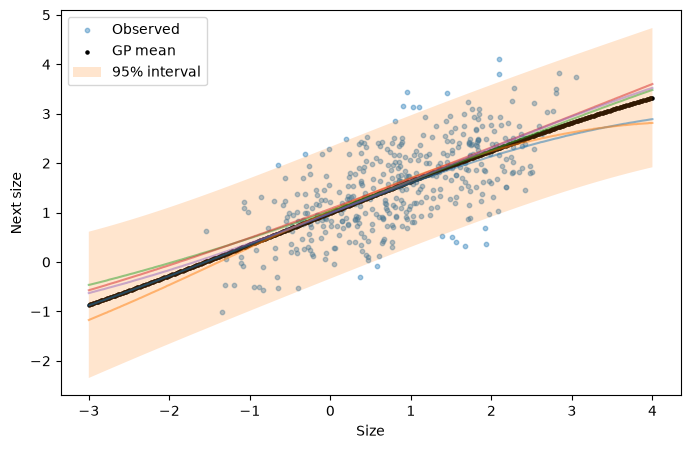

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_growth,
    Y_growth,
    s=10,
    alpha=0.4,
    label="Observed",
)

for i in range(growth_samples.shape[0]):
    plt.plot(
        X_grid.squeeze(),
        growth_samples[i],
        linewidth=1.5,
        alpha=0.5,
    )

plt.scatter(
    X_grid,
    mean,
    color="black",
    s=5,
    label="GP mean",
)
std = np.sqrt(var)
plt.fill_between(
    X_grid.flatten(),
    (mean - 2*std),
    (mean + 2*std),
    alpha=0.2,
    label="95% interval"

)

plt.xlabel("Size")

plt.ylabel("Next size")

plt.legend()

plt.show()

In [ ]:
from scipy.stats import norm

def growth_kernel(z_next, z_current, growth_function, grow_sd):
    
    mean_next = growth_function(z_current)
    return norm.pdf(
        z_next,
        loc=mean_next,
        scale=grow_sd
    )

# Survival

In [24]:
surv = sim_data.loc[
    sim_data["Surv"].notna(),
    ["z", "Surv"]
].copy()

X_surv = surv["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_surv = surv["Surv"].to_numpy().reshape(-1, 1).astype(np.float64)

print(X_surv.shape)
print(Y_surv.shape)

(966, 1)
(966, 1)


In [25]:
kernel_surv  = gp.kernels.SquaredExponential()

In [26]:
model_surv = gp.models.VGP(
    data=(X_surv, Y_surv),
    kernel=kernel_surv,
    likelihood=gp.likelihoods.Bernoulli(invlink = tf.sigmoid)
)

In [ ]:
optimizer = gp.optimizers.Scipy()

optimizer.minimize(
    model_surv.training_loss, # Negative Log Marginal Likelihood
    variables = model_surv.trainable_variables
    )

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 600.3518684730168
        x: [-2.794e-01  1.512e+00 ...  4.975e+00  7.381e+00]
      nit: 125
      jac: [-1.120e-02  8.479e-03 ... -6.279e-03  1.479e-03]
     nfev: 135
     njev: 135
 hess_inv: <468029x468029 LbfgsInvHessProduct with dtype=float64>

In [28]:
param_dict["surv_variance"] = model_surv.kernel.variance.numpy()
param_dict["surv_lengthscale"] = model_surv.kernel.lengthscales.numpy()


In [29]:
mean_surv, var_surv = model_surv.predict_y(X_grid)
mean_surv = mean_surv.numpy().squeeze()   # shape: (500,)
var_surv = var_surv.numpy().squeeze() # shape : (500,)

In [30]:
survival_function = interp1d(
    X_grid.squeeze(),
    mean_surv,
    kind="linear",
    fill_value="extrapolate",
    assume_sorted=True,
)

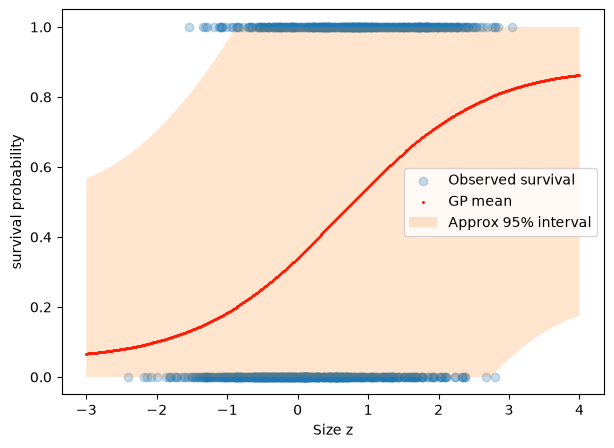

In [31]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_surv.squeeze(),
    Y_surv.squeeze(),
    alpha=0.25,
    label="Observed survival"
)

plt.scatter(
    X_grid,
    mean_surv,
    color="red",
    s=1,
    label="GP mean",
)
sd_surv = np.sqrt(var_surv.squeeze())

lower_surv = np.clip(mean_surv - 2 * sd_surv, 0.0, 1.0)
upper_surv = np.clip(mean_surv + 2 * sd_surv, 0.0, 1.0)
plt.fill_between(
    X_grid.flatten(),
    lower_surv,
    upper_surv,
    alpha=0.2,
    label="Approx 95% interval"

)

plt.xlabel("Size z")
plt.ylabel("survival probability")
plt.legend()
plt.show()

# Reproduction
$R \sim \mathrm{Bernoulli}(p_{\mathrm{repr}}(z))$

$p_{\mathrm{repr}}(z) = \sigma(f_{\mathrm{repr}}(z))$

$f_{\mathrm{repr}}(z) \sim GP(m(z), k(z,z'))$

In [32]:
# Reproduction / flowering data
repr_data = sim_data.loc[
    sim_data["Repr"].notna(),
    ["z", "Repr"]
].copy()

X_repr = repr_data["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_repr = repr_data["Repr"].to_numpy().reshape(-1, 1).astype(np.float64)

print(X_repr.shape)
print(Y_repr.shape)
print(Y_repr.sum())

# Kernel
kernel_repr = gp.kernels.SquaredExponential()

# Bernoulli GP with logistic/sigmoid link
model_repr = gp.models.VGP(
    data=(X_repr, Y_repr),
    kernel=kernel_repr,
    likelihood=gp.likelihoods.Bernoulli(invlink=tf.sigmoid),
)
optimizer = gp.optimizers.Scipy()
# Fit model
optimizer.minimize(
    model_repr.training_loss,
    variables=model_repr.trainable_variables,
)

(1000, 1)
(1000, 1)
34.0


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 48.52943699914001
        x: [-1.018e+00  1.158e+00 ...  3.875e+00  1.760e+02]
      nit: 320
      jac: [-3.876e-03  9.305e-04 ...  2.071e-03 -1.910e-05]
     nfev: 347
     njev: 347
 hess_inv: <501502x501502 LbfgsInvHessProduct with dtype=float64>

In [33]:
param_dict["repr_variance"] = model_repr.kernel.variance.numpy()
param_dict["repr_lengthscale"] = model_repr.kernel.lengthscales.numpy()

In [34]:
# Predict latent GP over grid
mean_repr, cov_repr = model_repr.predict_y(X_grid)

mean_repr = mean_repr.numpy().squeeze()
cov_repr = cov_repr.numpy().squeeze()

# Interpolate probability function
repr_function = interp1d(
    X_grid.squeeze(),
    mean_repr,
    kind="linear",
    fill_value="extrapolate",
    assume_sorted=True,
)

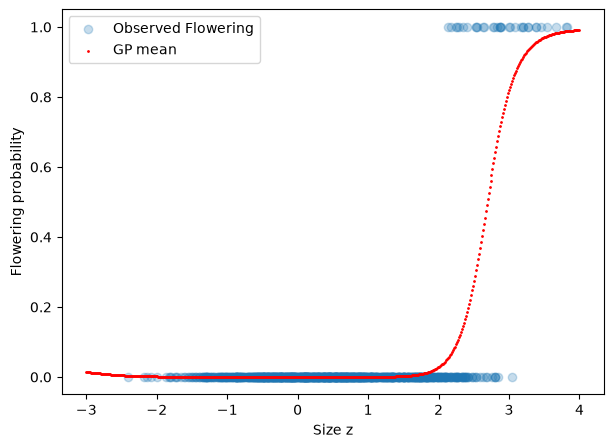

In [35]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_repr.squeeze(),
    Y_repr.squeeze(),
    alpha=0.25,
    label="Observed Flowering"
)

plt.scatter(
    X_grid,
    mean_repr,
    color="red",
    s=1,
    label="GP mean",
)

plt.xlabel("Size z")
plt.ylabel("Flowering probability")
plt.legend()
plt.show()

# Seed Production
$Seeds \sim \mathrm{Poisson}(\lambda(z))$

$\lambda(z) = \exp(f_{\mathrm{seed}}(z))$

$f_{\mathrm{seed}}(z) \sim GP(m(z), k(z,z'))$

In [36]:
# Seed production data
seed_data = sim_data.loc[
    sim_data["Seeds"].notna(),
    ["z", "Seeds"]
].copy()

X_seed = seed_data["z"].to_numpy().reshape(-1, 1).astype(np.float64)
Y_seed = seed_data["Seeds"].to_numpy().reshape(-1, 1).astype(np.float64)

print(X_seed.shape)
print(Y_seed.shape)

# Kernel
kernel_seed = gp.kernels.SquaredExponential()

# Poisson GP with log link
model_seed = gp.models.VGP(
    data=(X_seed, Y_seed),
    kernel=kernel_seed,
    likelihood=gp.likelihoods.Poisson(),
)

# Fit model
optimizer = gp.optimizers.Scipy()

optimizer.minimize(
    model_seed.training_loss,
    variables=model_seed.trainable_variables,
)

(34, 1)
(34, 1)


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 186.8929182175929
        x: [ 8.569e-01 -1.752e+00 ...  7.997e+00  1.004e+02]
      nit: 4066
      jac: [-2.056e-01 -4.320e-01 ... -7.052e-02 -4.127e-03]
     nfev: 4654
     njev: 4654
 hess_inv: <631x631 LbfgsInvHessProduct with dtype=float64>

In [37]:
param_dict["seed_variance"] = model_seed.kernel.variance.numpy()
param_dict["seed_lengthscale"] = model_seed.kernel.lengthscales.numpy()

In [38]:
# Predict latent GP over grid
mean_seed, cov_seed = model_seed.predict_y(X_grid)

mean_seed = mean_seed.numpy().squeeze()
cov_seed = cov_seed.numpy().squeeze()

# Interpolate expected seed production function
seed_function = interp1d(
    X_grid.squeeze(),
    mean_seed,
    kind="linear",
    fill_value="extrapolate",
    assume_sorted=True,
)

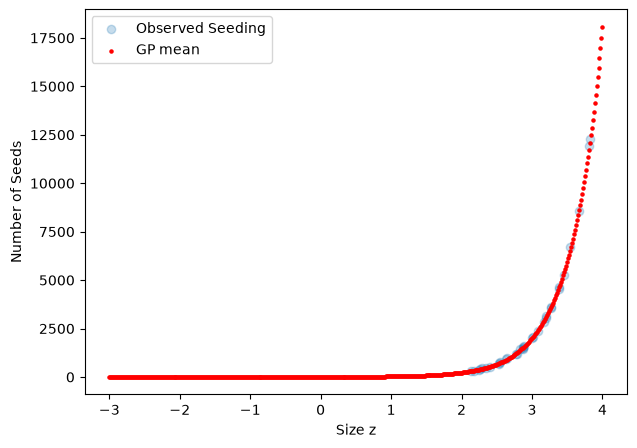

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_seed.squeeze(),
    Y_seed.squeeze(),
    alpha=0.25,
    label="Observed Seeding"
)

plt.scatter(
    X_grid.squeeze(),
    mean_seed,
    color="red",
    s=3,
    label="GP mean",
)

plt.xlabel("Size z")
plt.ylabel("Number of Seeds")
plt.legend()
plt.show()

# Recruitment

In [40]:
recruit_data = sim_data[sim_data["age"] == 0].copy()

recruit_mean_est = recruit_data["z"].mean()

# MLE uses ddof=0, not the default sample sd ddof=1
recruit_sd_est = recruit_data["z"].std(ddof=1)

n_recruits = (sim_data["age"] == 0).sum()
total_seeds = np.nansum(sim_data["Seeds"])

prob_recruit_est = n_recruits / total_seeds

print(f"recruit_mean: {recruit_mean_est}")
print(f"recruit_sd: {recruit_sd_est}")
print(f"recruit_mean: {prob_recruit_est}")

"""
recruit size
rcsz.int  =   -.08, 
rcsz.sd   =   0.76,
p.r       =   0.007
"""

recruit_mean: -0.053415729376288246
recruit_sd: 0.7508410117816402
recruit_mean: 0.006661383254439137


'\nrecruit size\nrcsz.int  =   -.08, \nrcsz.sd   =   0.76,\np.r       =   0.007\n'

In [70]:
n_init = 250

rng = np.random.default_rng(9)

# Initial population: random recruits, age 0
pop_df = pd.DataFrame({
    "id": np.arange(n_init),
    "z": rng.normal(loc=recruit_mean_est, scale=recruit_sd_est, size=n_init),
    "age": np.zeros(n_init, dtype=int),
})

next_id = n_init
records = []
n_years = 50

for year in range(1, n_years + 1):
    # Current population

    ids = pop_df["id"].to_numpy()
    z = pop_df["z"].to_numpy()
    age = pop_df["age"].to_numpy()
    n = len(pop_df)
    print(f"Year {year}:Current Population Size = {n}")

    # Flowering / reproduction
    p_repr = repr_function(z)
    p_repr = np.clip(p_repr, 0.0, 1.0)
    reproduced = rng.binomial(n=1, p=p_repr).astype(int)

    # Seeds: only for reproducing individuals
    n_seeds = np.full(n, np.nan)
    flower_idx = reproduced == 1
    if np.any(flower_idx):
        lam_seed = seed_function(z[flower_idx])
        lam_seed = np.clip(lam_seed, 0.0, None)
        n_seeds[flower_idx] = rng.poisson(lam_seed)

    # Survival: only for non-reproducing individuals
    survived = np.full(n, np.nan)
    nonflower_idx = reproduced == 0
    if np.any(nonflower_idx):
        p_surv = survival_function(z[nonflower_idx])
        p_surv = np.clip(p_surv, 0.0, 1.0)
        survived_nf = rng.binomial(n=1, p=p_surv).astype(int)
        survived[nonflower_idx] = survived_nf

    z1 = np.full(n, np.nan)

    keep_idx = (reproduced == 0) & (survived == 1)

    z_surv = z[keep_idx]
    age_surv = age[keep_idx] + 1
    ids_surv = ids[keep_idx]

    # Growth for survivors
    growth_mean = growth_function(z_surv)
    z_grown = growth_mean + np.sqrt(growth_noise_var) * rng.normal(size=z_surv.shape)

    z1[keep_idx] = z_grown

    # Store the current year's population record
    year_df = pd.DataFrame({
        "id": ids,
        "year": year,
        "z": z,
        "z1": z1,
        "age": age,
        "survived": survived,
        "reproduced": reproduced,
        "n_seeds": n_seeds,
    })
    records.append(year_df)

    # Total seeds and number of recruits
    total_seeds = int(np.nansum(n_seeds))
    n_recruits = rng.binomial(n=total_seeds, p=prob_recruit_est)

    # Recruit sizes, age 0
    recruits_z = rng.normal(
        loc=recruit_mean_est,
        scale=recruit_sd_est,
        size=n_recruits,
    )
    recruits_age = np.zeros(n_recruits, dtype=int)
    recruits_id = np.arange(next_id, next_id + n_recruits, dtype=int)
    next_id += n_recruits

    # Next year's population
    pop_df = pd.DataFrame({
        "id": np.concatenate([ids_surv, recruits_id]),
        "z": np.concatenate([z_grown, recruits_z]),
        "age": np.concatenate([age_surv, recruits_age]),
    })

# Final long dataframe
sim_df = pd.concat(records, ignore_index=True)

Year 1:Current Population Size = 250
Year 2:Current Population Size = 85
Year 3:Current Population Size = 44
Year 4:Current Population Size = 92
Year 5:Current Population Size = 229
Year 6:Current Population Size = 128
Year 7:Current Population Size = 106
Year 8:Current Population Size = 487
Year 9:Current Population Size = 444
Year 10:Current Population Size = 258
Year 11:Current Population Size = 533
Year 12:Current Population Size = 583
Year 13:Current Population Size = 535
Year 14:Current Population Size = 488
Year 15:Current Population Size = 903
Year 16:Current Population Size = 1085
Year 17:Current Population Size = 1569
Year 18:Current Population Size = 1065
Year 19:Current Population Size = 1401
Year 20:Current Population Size = 1828
Year 21:Current Population Size = 2230
Year 22:Current Population Size = 2453
Year 23:Current Population Size = 2682
Year 24:Current Population Size = 2699
Year 25:Current Population Size = 4049
Year 26:Current Population Size = 4446
Year 27:Curre

In [71]:
param_dict

{'growth_variance': array(14.96577625),
 'growth_lengthscale': array(9.27113501),
 'growth_noise_variance': array(0.44178767),
 'surv_variance': array(7.3820793),
 'surv_lengthscale': array(4.98182209),
 'repr_variance': array(175.9508922),
 'repr_lengthscale': array(3.8957832),
 'seed_variance': array(100.37153032),
 'seed_lengthscale': array(7.99736046)}

In [72]:
pd.set_option("display.float_format", "{:.3f}".format)
sim_df.describe()

,id,year,z,z1,age,survived,reproduced,n_seeds
count,1159440.000,1159440.000,1159440.000,473569.000,1159440.000,1113283.000,1159440.000,46157.000
mean,345287.192,43.750,0.501,1.513,0.649,0.425,0.040,2819.471
std,206799.354,6.545,1.100,0.897,1.135,0.494,0.196,4247.771
min,0.000,1.000,-3.431,-2.528,0.000,0.000,0.000,0.000
25%,167909.000,41.000,-0.293,0.901,0.000,0.000,0.000,828.000
50%,336762.500,46.000,0.379,1.517,0.000,0.000,0.000,1522.000
75%,514511.250,49.000,1.224,2.132,1.000,1.000,0.000,2993.000
max,749103.000,50.000,5.554,5.554,14.000,1.000,1.000,78652.000


In [73]:
sim_df_copy = sim_df[sim_df["year"] > 10].copy()

sim_df_copy["year"] = sim_df_copy["year"] - 10

In [74]:
dataset_sizes = [250,500,750,1000,2000]
dataset_dict = {}

for n in dataset_sizes:
    data_sample = sim_df_copy.sample(
    n=n,
    replace=False,
    random_state=53241986
    )
    dataset_dict[f"sim_df_copy{n}"] = data_sample
    data_sample.to_csv(f"gp_sample{n}.csv", index=False)

In [45]:
def recruit_size_density(z_next, recruit_mean, recruit_sd):
    return norm.pdf(
        z_next,
        loc=recruit_mean,
        scale=recruit_sd,
    )

In [46]:
def P_z1z_gp(z_next, z_current):
    p_repr = np.clip(repr_function(z_current), 0.0, 1.0)
    p_surv = np.clip(survival_function(z_current), 0.0, 1.0)

    grow_sd = np.sqrt(float(np.asarray(growth_noise_var)))

    return (
        (1.0 - p_repr)
        * p_surv
        * norm.pdf(
            z_next,
            loc=growth_function(z_current),
            scale=grow_sd,
        )
    )

In [47]:
def F_z1z_gp(z_next, z_current):
    p_repr = np.clip(repr_function(z_current), 0.0, 1.0)
    expected_seeds = np.clip(seed_function(z_current), 0.0, None)

    return (
        p_repr
        * expected_seeds
        * prob_recruit_est
        * recruit_size_density(
            z_next,
            recruit_mean_est,
            recruit_sd_est,
        )
    )

In [48]:
def make_gp_ipm(n_mesh_points=250, lower_size=-3.0, upper_size=4.6):
    mesh_width = (upper_size - lower_size) / n_mesh_points

    mesh_points = (
        lower_size
        + (np.arange(n_mesh_points) + 0.5)
        * mesh_width
    )

    z_next_grid, z_current_grid = np.meshgrid(
        mesh_points,
        mesh_points,
        indexing="ij",
    )

    P = mesh_width * P_z1z_gp(z_next_grid, z_current_grid)
    F = mesh_width * F_z1z_gp(z_next_grid, z_current_grid)
    K = P + F

    return {
        "K": K,
        "P": P,
        "F": F,
        "mesh_points": mesh_points,
        "mesh_width": mesh_width,
        "lower_size": lower_size,
        "upper_size": upper_size,
    }



In [49]:
gp_ipm = make_gp_ipm(
    n_mesh_points=250,
    lower_size=-3.5,
    upper_size=6.0,
)

In [50]:
eigenvalues, eigenvectors = np.linalg.eig(gp_ipm["K"])

dominant_index = np.argmax(eigenvalues.real)
lambda_gp = eigenvalues[dominant_index].real

stable_distribution = eigenvectors[:, dominant_index].real
stable_distribution = np.abs(stable_distribution)
stable_distribution = stable_distribution / stable_distribution.sum()

mean_stable_size = np.sum(
    stable_distribution
    * gp_ipm["mesh_points"]
)

print(f"GP IPM lambda: {lambda_gp:.4f}")
print(f"Mean stable size: {mean_stable_size:.4f}")

GP IPM lambda: 1.1568
Mean stable size: 0.5004
